<a href="https://colab.research.google.com/github/WPHdamian/Data-Science-Curriculum-Analysis-/blob/main/B3_Market_TopicModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 3 - Topic Modelling of Data Science Curricula

This section applies Latent Dirichlet Allocation (LDA) to module-level curriculum texts
to uncover latent thematic structures in Data Science programmes across Hong Kong and London.

Input:
- Parquet file generated from section 1
- Column used for modelling: `clean_tokens` (bigrams & trigrams)

Outputs:
- All figures saved to `Output/`
- Updated dataframe with topic assignments saved as parquet

Reproducibility:
- Fixed random seed
- Explicit package versions


### 3.2 Environment Setup

This section:
- Loads required libraries
- Fixes random seeds
- Logs package versions for reproducibility


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
import numpy as np
import os
import random

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

OUTPUT_DIR = "Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### 3.3 Data Loading

We load the cleaned curriculum dataset produced in Notebook 1.
Only the final processed text field, biagrams and trigrams will be used for topic modelling.


In [ ]:
df = pd.read_parquet("job.parquet")
df.head()

,job_id,keyword,location,month,title,company,detail,description,extracted_skills
0,4026274969,Big Data,London,nov,Associate,AI Futures,On-site Full-time,About the job\nAssociate Consultant | AI Staff...,"[""Niche recruitment"", ""Data or Tech recruitmen..."
1,4054500393,Data Analytics,Hong Kong,nov,Media Executive (Fresh Graduate Welcome),dentsu,On-site Full-time,About the job\nResponsibilities\nWorking with ...,"[""Account Management"", ""Communication Planning..."
2,4065898107,Big Data,London,nov,Intermediate Java Developer,Global Relay,Hybrid Full-time,About the job\nWho we are:\n\nFor over 20 year...,"[""Java"", ""Agile development methodologies"", ""T..."
3,4112637377,"Data Analyst, Data Analytics, Data Science",Hong Kong,nov,Senior Product Data Analyst,Crypto.com,Hybrid Full-time,About the job\nOur Product Management team dri...,"[""Data analysis"", ""Product management"", ""SQL"",..."
4,4130605940,Data Science,London,nov,"Senior Product Manager, Global Payments",Blockchain.com,On-site Full-time,About the job\nBlockchain.com is connecting th...,"[""Product Management"", ""Payments"", ""Fiat suppo..."


In [ ]:
df.columns=['job_id', 'keyword', 'location', 'month', 'title', 'company', 'detail',
       'description', 'clean_tokens']

### 3.4 Selecting Number of Topics (K)

LDA performance depends on the choice of topic number K.

We evaluate models across a range of K values using coherence scores
(c_v metric), which captures semantic interpretability.

This step is performed:
- Overall
- Separately for each city (London, Hong Kong)


In [ ]:
import ast
from gensim import corpora

def safe_tokenize(x):
    if isinstance(x, str):
        # Trim leading/trailing whitespaces
        x_stripped = x.strip()
        # Check if it looks like a stringified list or dictionary structure
        if x_stripped.startswith('[') and x_stripped.endswith(']'):
            try:
                return ast.literal_eval(x_stripped)
            except (ValueError, SyntaxError):
                pass
        # Fallback: if it's a standard space-separated string, split it into single words
        return x_stripped.split()
    elif isinstance(x, list):
        return x
    else:
        # Fallback for NaN / float / None values
        return []

# Apply the robust tokenizer function
df["clean_tokens"] = df["clean_tokens"].apply(safe_tokenize)

# Initialize the Gensim Dictionary mapping
dictionary = corpora.Dictionary(df["clean_tokens"])

# Filter out rare words and overly common stop-words
dictionary.filter_extremes(
    no_below=5,     # Word must appear in at least 5 documents
    no_above=0.8    # Word cannot appear in more than 80% of documents
)

# Compile into Bag-of-Words (BoW) tuples (token_id, token_count)
corpus = [dictionary.doc2bow(tokens) for tokens in df["clean_tokens"]]

print("Vocabulary Size:", len(dictionary))
print("Total Documents Processed:", len(corpus))

Vocabulary Size: 2175
Total Documents Processed: 4147


#### 3.4.1 Coherence Function

In [ ]:
import pandas as pd
from gensim.models import CoherenceModel, LdaMulticore
import time

def tune_lda(dictionary, corpus, texts, k_range, alpha_list, eta_list, passes_list):
    results = []

    # Calculate total iterations for progress tracking
    total_models = len(k_range) * len(alpha_list) * len(eta_list) * len(passes_list)
    print(f"Testing {total_models} total combinations...\n")

    count = 0
    for k in k_range:
        for a in alpha_list:
            for e in eta_list:
                for p in passes_list:
                    count += 1
                    start_time = time.time()

                    # Train model
                    model = LdaMulticore(
                        corpus=corpus,
                        id2word=dictionary,
                        num_topics=k,
                        alpha=a,
                        eta=e,
                        passes=p,
                        random_state=SEED,
                        workers=3 # Adjust based on your CPU cores
                    )

                    # Calculate Coherence (c_v is generally best for human interpretability)
                    coherence_model = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
                    score = coherence_model.get_coherence()

                    duration = time.time() - start_time
                    results.append([k, a, e, p, score])

                    print(f"[{count}/{total_models}] K:{k} Alpha:{a} Eta:{e} Passes:{p} -> Coherence: {score:.4f} ({duration:.1f}s)")

    return pd.DataFrame(results, columns=['K', 'Alpha', 'Eta', 'Passes', 'Coherence'])

# --- Configuration ---
k_range = range(3, 6)   # 3, 4, 5, 6, 7
alphas = ['symmetric', 'asymmetric', 0.01]
etas = ['auto', 0.1]
passes = [20, 50]

# Run the tuning (Ensure 'processed_texts' is your list of tokenized words)
df_results = tune_lda(dictionary, corpus, df["clean_tokens"], k_range, alphas, etas, passes)

# --- Find the Winner ---
best_row = df_results.loc[df_results['Coherence'].idxmax()]
print("\n" + "="*30)
print("BEST MODEL PARAMETERS:")
print(best_row)
print("="*30)

Testing 36 total combinations...

[1/36] K:3 Alpha:symmetric Eta:auto Passes:20 -> Coherence: 0.5832 (18.5s)
[2/36] K:3 Alpha:symmetric Eta:auto Passes:50 -> Coherence: 0.5946 (22.6s)
[3/36] K:3 Alpha:symmetric Eta:0.1 Passes:20 -> Coherence: 0.5867 (17.8s)
[4/36] K:3 Alpha:symmetric Eta:0.1 Passes:50 -> Coherence: 0.5855 (22.3s)
[5/36] K:3 Alpha:asymmetric Eta:auto Passes:20 -> Coherence: 0.5656 (18.8s)
[6/36] K:3 Alpha:asymmetric Eta:auto Passes:50 -> Coherence: 0.5742 (22.4s)
[7/36] K:3 Alpha:asymmetric Eta:0.1 Passes:20 -> Coherence: 0.6290 (17.5s)
[8/36] K:3 Alpha:asymmetric Eta:0.1 Passes:50 -> Coherence: 0.5930 (21.7s)
[9/36] K:3 Alpha:0.01 Eta:auto Passes:20 -> Coherence: 0.5883 (16.9s)
[10/36] K:3 Alpha:0.01 Eta:auto Passes:50 -> Coherence: 0.5925 (21.0s)
[11/36] K:3 Alpha:0.01 Eta:0.1 Passes:20 -> Coherence: 0.5918 (16.9s)
[12/36] K:3 Alpha:0.01 Eta:0.1 Passes:50 -> Coherence: 0.5973 (21.2s)
[13/36] K:4 Alpha:symmetric Eta:auto Passes:20 -> Coherence: 0.6063 (18.2s)
[14/36] K

best model based on CV score is
- K         :            4
- Alpha     :   asymmetric
- Eta       :          0.1
- Passes    :           20
- Coherence:      0.628957

In [ ]:
def compute_coherence_values(dictionary, corpus, texts, k_range):
    coherence_scores = []

    for k in k_range:
        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=SEED,
            passes=20,
            alpha="asymmetric",
            eta=0.1
        )

        coherence_model = CoherenceModel(
            model=lda,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )

        coherence_scores.append(coherence_model.get_coherence())

    return coherence_scores



#### 3.4.2 Plot Coherence vs K (Overall)

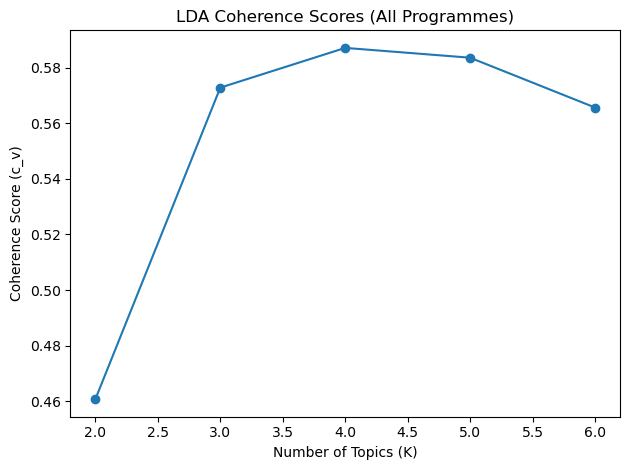

In [ ]:
#double check if fewer topics have better performance
k_range = range(2, 7)
coherence_scores = compute_coherence_values(
    dictionary, corpus, df["clean_tokens"], k_range
)

plt.figure()
plt.plot(k_range, coherence_scores, marker="o")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Coherence Scores (All Programmes)")
plt.tight_layout()
plt.savefig("Output/lda_coherence_curve.png", dpi=300, bbox_inches="tight")
plt.show()


The best k is found to be 3, with cv_score of 0.628957

In [ ]:
optimal_k = 4
#print(f"Optimal K is: {optimal_k}, with a cv_score of {max(coherence_scores)}")

#### 3.4.3 Final Topic Model

Based on coherence analysis, we select the optimal K
and estimate the final LDA model for interpretation.


In [ ]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    passes=20,
    alpha='asymmetric',
    eta=0.1,
    random_state=SEED
)


#### Topic term distributions

In [ ]:
def show_topics(model, num_words=12):
    topics = model.show_topics(num_topics=5, num_words=num_words, formatted=False)
    for topic_num, words in topics:
        terms = [w for w, _ in words]
        print(f"\nTOPIC {topic_num+1}")
        print("Keywords:", " | ".join(terms))

show_topics(lda_model)


TOPIC 1
Keywords: Communication | Data Analysis | Excel | Project Management | Communication Skills | English | Collaboration | SQL | Analytical Skills | Stakeholder Management | Attention to Detail | Leadership

TOPIC 2
Keywords: Communication skills | Data analysis | Analytical skills | Project management | Interpersonal skills | Attention to detail | Problem-solving | Time management | Stakeholder management | Presentation skills | Collaboration | Problem-solving skills

TOPIC 3
Keywords: Python | Machine Learning | SQL | AWS | GCP | Data Science | Azure | PyTorch | React | Java | Docker | R

TOPIC 4
Keywords: SQL | Python | Data Engineering | Databricks | AWS | Snowflake | Airflow | Terraform | Data Governance | Automation | Azure | APIs


- **Topic 1: Business Operations and Management**
- **Topic 2: Soft Skills and Professional Attributes**
- **Topic 3: Data Science and Software Development**
- **Topic 4: Data Engineering and Infrastructure**

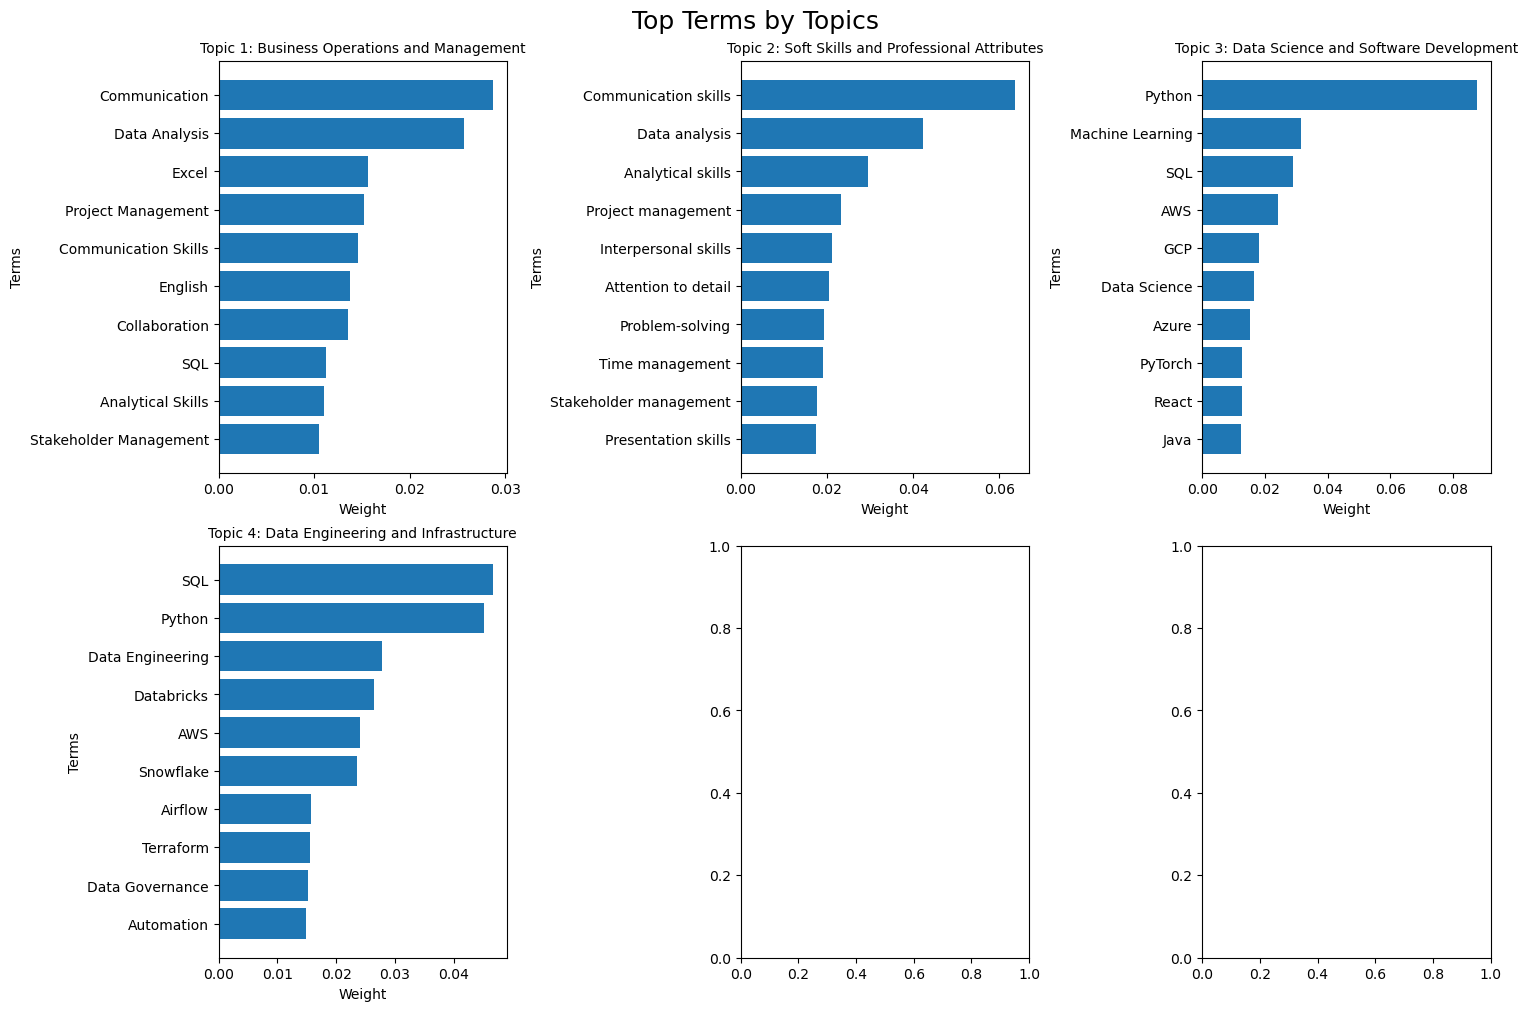

In [ ]:
# Define the topic labels
topic_labels = [
    "Business Operations and Management",
    "Soft Skills and Professional Attributes",
    "Data Science and Software Development",
    "Data Engineering and Infrastructure",
]

# Create a figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)

# Loop through each topic and plot on the corresponding subplot
for topic_id in range(optimal_k):
    terms = lda_model.show_topic(topic_id, topn=10)
    words, weights = zip(*terms)

    # Select the corresponding subplot
    ax = axes[topic_id // 3, topic_id % 3]
    ax.barh(words, weights)
    ax.invert_yaxis()
    ax.set_title(f"Topic {topic_id+1}: {topic_labels[topic_id]}", fontsize=10)
    ax.set_xlabel("Weight")
    ax.set_ylabel("Terms")

# Adjust spacing and save the figure
fig.suptitle("Top Terms by Topics", fontsize=18)
plt.savefig("Output/topics_subplots.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.5 Topic Assignment at Module Level
#### 3.5.1 Dominant Topic per Module


In [ ]:
topic_distributions = lda_model.get_document_topics(corpus, minimum_probability=0)

dominant_topics = []
topic_probs = []

for dist in topic_distributions:
    if dist:
        top_topic = max(dist, key=lambda x: x[1])
        dominant_topics.append(top_topic[0] + 1)  # +1 for readability
        topic_probs.append(top_topic[1])
    else:
        dominant_topics.append(None)
        topic_probs.append(None)

df["dominant_topic"] = dominant_topics
df["topic_probability"] = topic_probs

df[["job_id", "dominant_topic", "topic_probability"]].head()

,job_id,dominant_topic,topic_probability
0,4026274969,1,0.389610
1,4054500393,1,0.865973
2,4065898107,3,0.926245
3,4112637377,2,0.797081
4,4130605940,2,0.957746


## **3.6 Comparative Analysis: City-Level Topic Profiles**

Purpose:
- Test whether the distribution of dominant topics differs between **Hong Kong** and **London**.

#### 3.6.1 Topic Distribution by City (Descriptive Overview)

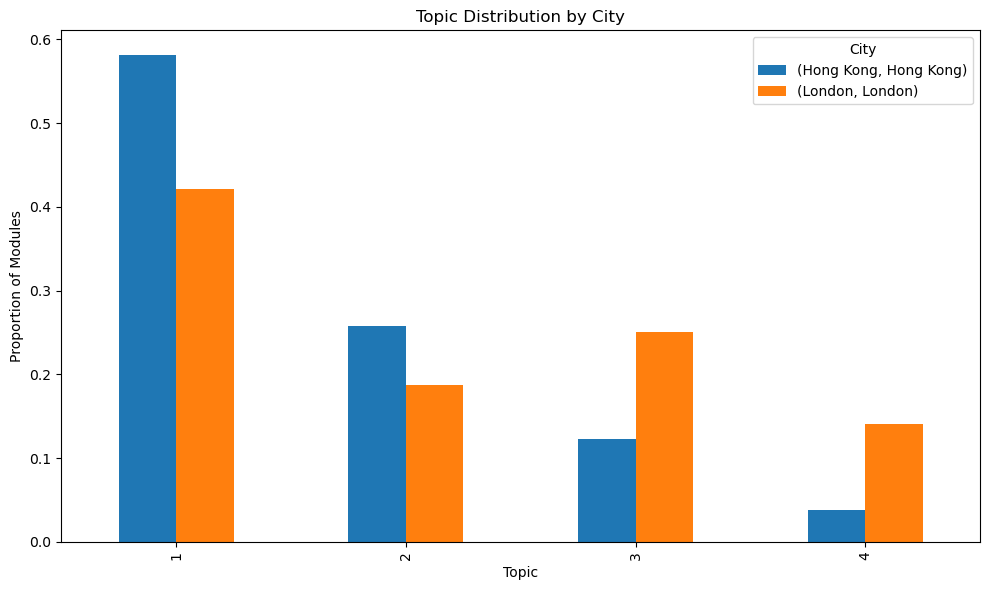

In [ ]:
topic_city_dist = (
    df.groupby(["location", "dominant_topic"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

ax = topic_city_dist.T.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Topic")
plt.ylabel("Proportion of Modules")
plt.title("Topic Distribution by City")
plt.legend(title="City")
plt.tight_layout()
plt.show()

#### 3.6.2a Chi-Square Test of Independence (City × Topic)

Next, we test whether curriculum topic distributions differ systematically between London and Hong Kong.

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["location"], df["dominant_topic"])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.4f}")


Chi-square statistic: 271.791
p-value: 0.0000


#### 3.6.2b Effect Size: Cramér’s V

In [ ]:
import numpy as np

n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"Cramér’s V: {cramers_v:.3f}")


Cramér’s V: 0.256


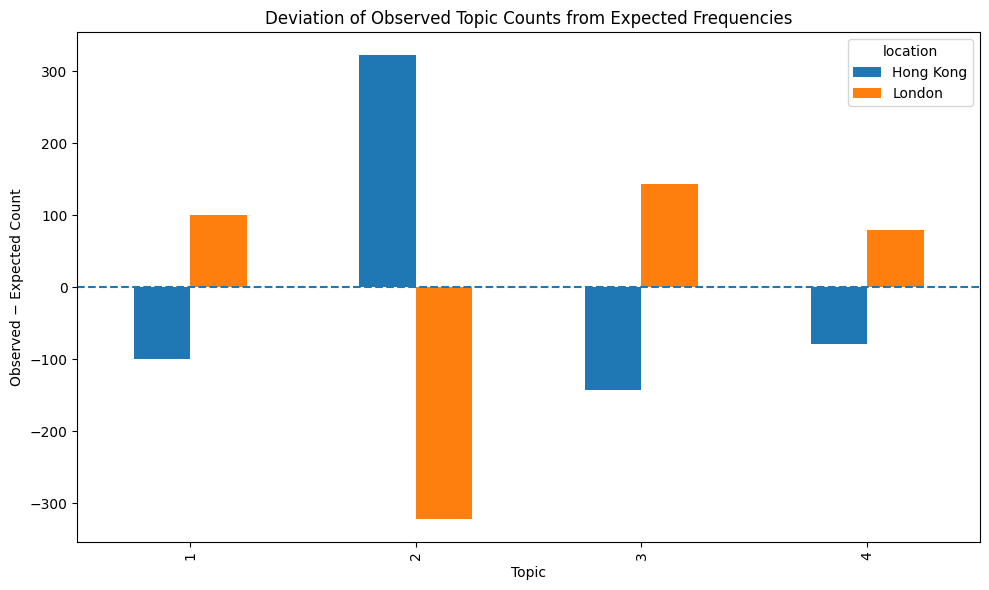

In [ ]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

(contingency - expected_df).T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(0, linestyle="--")
plt.xlabel("Topic")
plt.ylabel("Observed − Expected Count")
plt.title("Deviation of Observed Topic Counts from Expected Frequencies")
plt.tight_layout()
plt.show()


#### 3.6.3 Jensen–Shannon Divergence (Overall Curriculum Orientation)

We quantify the overall divergence between curriculum topic profiles across cities.

In [ ]:
from scipy.spatial.distance import jensenshannon
import numpy as np

p_london = topic_city_dist.loc["London"].values
p_hk = topic_city_dist.loc["Hong Kong"].values

p_london = np.asarray(p_london).flatten()
p_hk = np.asarray(p_hk).flatten()

js_divergence = jensenshannon(p_london, p_hk)

print(f"Jensen–Shannon Divergence: {js_divergence:.4f}")


Jensen–Shannon Divergence: 0.1904


#### 3.6.4 Curriculum Breadth: Topic Entropy

We compare curriculum breadth versus specialisation between cities.

In [ ]:
from scipy.stats import entropy

entropy_london = entropy(p_london)
entropy_hk = entropy(p_hk)

print(f"Topic Entropy (London): {entropy_london:.3f}")
print(f"Topic Entropy (Hong Kong): {entropy_hk:.3f}")

Topic Entropy (London): 1.300
Topic Entropy (Hong Kong): 1.045


### 3.7 Summary

This notebook identified latent curricular themes in Data Science programmes
using LDA topic modelling. Topics were selected via coherence optimisation and
assigned at the module level.

Outputs from this notebook:
- Topic-term visualisations
- City-level topic distributions
- Module-level topic labels (saved in parquet)

These results form the basis for:
- Curriculum orientation analysis (RQ1)
- Mapping topics to EDISON competence domains (Notebook 3)
- Curriculum–labour market alignment (RQ2)


In [ ]:
df.to_parquet("job_lda.parquet", index=False)

In [ ]:
!pip install pyLDAvis

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 13.6 MB/s eta 0:00:00


In [ ]:
# Interactive visualization with pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary, R=15,sort_topics=False)
vis  # Displays interactive view in notebook


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.150647 -0.321979       1        1  46.935004
1     -0.297614  0.230580       2        1  19.635742
2      0.215580  0.067146       3        1  20.672032
3      0.232681  0.024253       4        1  12.757222, topic_info=                     Term         Freq        Total Category  logprob  loglift
54                 Python  1082.000000  1082.000000  Default  15.0000  15.0000
32   Communication skills   552.000000   552.000000  Default  14.0000  14.0000
25          Data analysis   366.000000   366.000000  Default  13.0000  13.0000
29                    SQL   821.000000   821.000000  Default  12.0000  12.0000
154      Machine Learning   287.000000   287.000000  Default  11.0000  11.0000
..                    ...          ...          ...      ...      ...      ...
174                 CI/CD    69.287568    99.384541   Topic4  -4.3983   1.6983
229            Automation    83.605755   158.510415   Topic4  -4.2104   1.4194
70                   APIs    70.226422   106.862068   Topic4  -4.3848   1.6393
74                  Azure    80.129267   219.321259   Topic4  -4.2529   1.0522
681        Data pipelines    60.300548    91.523368   Topic4  -4.5372   1.6418

[107 rows x 6 columns], token_table=      Topic      Freq             Term
term                                  
70        3  0.336883             APIs
70        4  0.655050             APIs
73        3  0.620559              AWS
73        4  0.380162              AWS
56        4  0.991841          Airflow
...     ...       ...              ...
9         1  0.997126  Time Management
108       2  0.995163  Time management
391       3  0.995302       TypeScript
675       1  0.996858              and
216       4  0.986539              dbt

[121 rows x 3 columns], R=15, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4])